# Assignment 5: Monitoring & Governance

## Wo befinden wir uns im MLOps-Projekt?

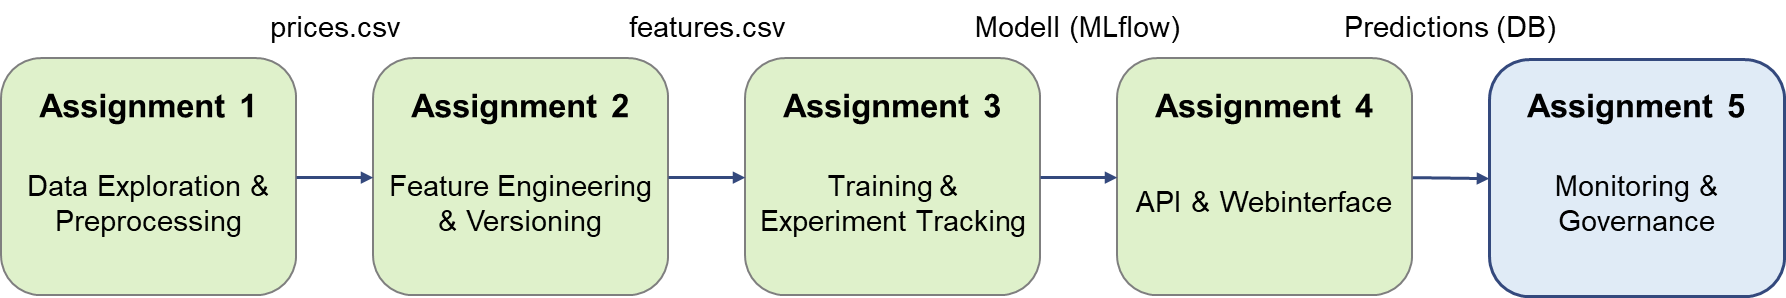

## Was passiert in diesem Notebook?

Sie überwachen die Modellqualität in der Produktion. Das Notebook besteht aus zwei Teilen:

**Teil 1 – Produktions-RMSE (Baseline messen):** Sie berechnen den echten Vorhersagefehler aus den Vorhersagen, die A4 bereits getroffen hat und für die der tatsächliche Preis inzwischen bekannt ist. Dazu fragen Sie mindestens 10 historische Zeitstempel über die API ab (gültiger Zeitraum: 15.02.2025 – heute) und vergleichen den Produktions-RMSE mit den Offline-Metriken aus A3.

**Teil 2 – Data Drift Detection (Evidently):** Sie erkennen, ob sich die Eingabedaten signifikant verändert haben. Das kann z.B. durch Energiekrisen passieren. Das Tool Evidently erstellt einen visuellen HTML-Report mit statistischen Tests pro Feature. Anschließend diskutieren Sie, was der erkannte Drift für die Modellqualität bedeutet und ob Handlungsbedarf besteht.

**Voraussetzung:** A2 abgeschlossen (features.csv vorhanden), A4 abgeschlossen (Vorhersagen in DB)

**Ausgabe:** reports/drift_report.html + reports/drift_summary.json

---

**Funktionen zu implementieren:**
| Funktion | Beschreibung |
|---|---|
| compute_production_rmse() | Echten RMSE aus API-Vorhersagen berechnen |
| load_reference_data() | Trainingsperiode bis 31.12.2025 laden (Referenz) |
| load_current_data() | Aktuelle Daten ab 01.01.2026 laden (enthält realen Drift ab März 2026) |
| generate_drift_report() | Evidently-Report erstellen (vorgegeben) |
| run_monitoring() | Alle Schritte orchestrieren |

## Bewertungskriterien (6 Punkte)

| Kriterium | Punkte |
|---|---|
| Drift-Report mit Evidently (HTML-Report, realer Drift erkannt, interpretiert) | 4 |
| Produktions-RMSE / Feedback Loop (echte Preise mit Vorhersagen abgeglichen) | 2 |
| **Gesamt** | **6** |

**Abgabe: 18.06.2026 um 23:59 Uhr**

---

## Aufbau dieses Notebooks

Dieses Notebook ist in zwei Teile gegliedert, die nacheinander bearbeitet werden:

**Teil 1 – Produktions-RMSE (Baseline messen)**
Messen Sie zuerst den aktuellen Stand: Wie gut performt das Modell auf echten Vorhersagen
aus A4? Dazu rufen Sie `/predict` für mindestens 10 historische Zeitstempel auf
(gültiger Zeitraum: 15.02.2025 – heute) und berechnen den RMSE aus den gespeicherten
Vorhersagen. Anschließend vergleichen Sie Produktions-RMSE, Test-RMSE und Train-RMSE
aus A3 in einer Tabelle.

**Teil 2 – Data Drift Detection (Evidently)**
Im zweiten Teil laden Sie Referenzdaten (Trainingsperiode bis 31.12.2025) und aktuelle
Daten (ab 01.01.2026). Anfang März 2026 stiegen die Kraftstoffpreise infolge eines
geopolitischen Konflikts abrupt um 25–30% – dieser reale Drift ist bereits in den Daten
vorhanden. Evidently erstellt einen visuellen HTML-Report mit statistischen Tests pro
Feature. Abschließend diskutieren Sie, was der erkannte Drift für die Modellqualität
bedeutet und ob Handlungsbedarf besteht.

In [ ]:
import os, sys, json
import math

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import psycopg2

from config import GROUP_ID, DB_CONFIG, STATION_ID, DEFAULT_PARAMS, FUEL_TYPE

params        = DEFAULT_PARAMS
features_path = os.path.join(PROJECT_ROOT, params["paths"]["processed"])
report_path   = os.path.join(PROJECT_ROOT, params["paths"]["drift_report"])
json_path     = os.path.join(PROJECT_ROOT, "reports", "drift_summary.json")

# Feature-Spalten dynamisch aus features.csv lesen (konsistent mit A2/A3/predict.py)
EXCLUDE_COLS = ["datetime", f"{FUEL_TYPE}_price", f"{FUEL_TYPE}_price_next_hour"]
if os.path.exists(features_path):
    _cols = pd.read_csv(features_path, nrows=0).columns.tolist()
    FEATURE_COLS = [c for c in _cols if c not in EXCLUDE_COLS]
else:
    # Fallback (features.csv noch nicht vorhanden)
    FEATURE_COLS = [
        "hour", "day_of_week", "month", "is_weekend",
        f"{FUEL_TYPE}_lag_1h", f"{FUEL_TYPE}_lag_2h", f"{FUEL_TYPE}_lag_24h", f"{FUEL_TYPE}_lag_168h",
        f"{FUEL_TYPE}_ma_24h", f"{FUEL_TYPE}_diff_1h", f"{FUEL_TYPE}_diff_24h",
    ]

print(f"Gruppe    : {GROUP_ID}")
print(f"Kraftstoff: {FUEL_TYPE}")
print(f"Features  : {features_path}")
print(f"Report    : {report_path}")
print(f"Feature-Spalten ({len(FEATURE_COLS)}): {FEATURE_COLS}")

---
# Teil 1: Produktions-RMSE – Baseline messen

Bevor wir Drift simulieren, etablieren wir eine **Baseline**: Wie gut ist das Modell
aktuell auf echten Produktions-Vorhersagen?

```
Feedback Loop:
  1. A4 erstellt Vorhersage: predictions.predicted_price = 1.799 EUR/L
  2. Echter Preis tritt ein: actual_price              = 1.789 EUR/L
  3. Fehler:                 |1.799 - 1.789|           = 0.010 EUR/L
  4. RMSE = sqrt(mean(alle Fehler²))
```

**Warum zuerst die Baseline?**
Erst wenn Sie wissen, wie gut das Modell *jetzt* ist, können Sie beurteilen,
ob ein erkannter Drift tatsächlich zu Qualitätsverlust geführt hat.

> **Realer Hintergrund – Energiekrise März 2026:** Anfang März 2026 stiegen
> die Kraftstoffpreise in Deutschland infolge eines geopolitischen Konflikts
> abrupt um 25–30% innerhalb weniger Tage. In Ihren API-Anfragen (unten)
> befinden sich Zeitstempel aus dieser Periode (`2026-03-01`). Vergleichen Sie
> später, ob der Produktions-RMSE für diese Zeitpunkte deutlich höher liegt
> als für ruhige Perioden.

---

### Schritt 1: Vorhersagen über die API abrufen (Voraussetzung für RMSE)

`compute_production_rmse()` liest die Tabelle `predictions` aus der Datenbank und
vergleicht `predicted_price` mit `actual_price`. Damit das funktioniert, müssen Sie
zuerst **mindestens 10 Vorhersagen** über Ihren `/predict`-Endpoint abgerufen haben.

**Gültiger Zeitraum für Zeitstempel:**

| Grenze | Datum | Grund |
|---|---|---|
| Untergrenze | 15.02.2025 | Frühester verfügbarer Benzinpreis in der DB |
| Obergrenze | heute (Ausführungsdatum) | Zukünftige Preise sind noch unbekannt → `actual_price = NULL` → fließen **nicht** in den RMSE ein |

Zeitstempel außerhalb dieses Fensters werden zwar von `/predict` akzeptiert und
gespeichert, liefern aber kein `actual_price` und erhöhen damit die Stichprobengröße
des RMSE nicht.

**Wichtig:** Verteilen Sie die Zeitstempel gleichmäßig über den gesamten gültigen
Zeitraum (Feb 2025 – heute). Nur so repräsentiert der RMSE verschiedene
Betriebsbedingungen (Wochentage, Jahreszeiten, unterschiedliche Preisniveaus).
Der Zeitraum **März 2026** ist besonders aufschlussreich – schließen Sie ihn bewusst ein.

Starten Sie zunächst die API (`uvicorn app.main:app --reload --port 8000`),
dann führen Sie die folgende Zelle aus:

In [ ]:
# Voraussetzung: API läuft im Terminal:
#   cd ~/mlops-gasprices
#   uvicorn app.main:app --reload --host 0.0.0.0 --port $(python -c "from config import API_PORT; print(API_PORT)")

import os, requests
from config import GROUP_ID, API_PORT

# Requests immer über localhost:<API_PORT> – uvicorn läuft im selben Container.
# Die JupyterHub-URL ist nur für den Browser gedacht.
BASE_URL = f"http://localhost:{API_PORT}"

_jhub = os.environ.get("JUPYTERHUB_SERVICE_PREFIX", "").rstrip("/")
if _jhub:
    browser_url = f"http://141.47.5.55:8000{_jhub}/proxy/{API_PORT}"
    print(f"JupyterHub erkannt – Browser-URL: {browser_url}")
print(f"API-Requests an: {BASE_URL}  (Port {API_PORT})\n")

# Gültiger Zeitraum: 15.02.2025 bis heute (Preise werden täglich aktualisiert)
timestamps = [
    "2025-02-20T08:00:00",   # Feb 2025,  Winter,   morgens
    "2025-04-05T14:00:00",   # Apr 2025,  Frühling, nachmittags
    "2025-06-15T07:00:00",   # Jun 2025,  Sommer,   frühmorgens
    "2025-08-10T18:00:00",   # Aug 2025,  Sommer,   abends
    "2025-10-03T09:00:00",   # Okt 2025,  Herbst,   morgens
    "2025-12-24T16:00:00",   # Dez 2025,  Winter,   nachmittags
    "2026-01-10T07:00:00",   # Jan 2026,  Winter,   frühmorgens
    "2026-03-01T12:00:00",   # Mär 2026,  Frühling, mittags
    "2026-04-20T17:00:00",   # Apr 2026,  Frühling, abends
    "2026-06-01T10:00:00",   # Jun 2026,  Sommer,   morgens
]

print(f"Sende {len(timestamps)} Vorhersage-Anfragen ...\n")
for ts in timestamps:
    try:
        r = requests.post(f"{BASE_URL}/predict", json={"predict_for": ts}, timeout=10)
        if r.status_code == 200:
            d = r.json()
            print(f"  {ts}  →  {d['predicted_price']:.4f} EUR/L  (Modell v{d['model_version']})")
        else:
            print(f"  {ts}  →  Fehler {r.status_code}: {r.text[:80]}")
    except requests.exceptions.ConnectionError:
        print(f"  ✗ API nicht erreichbar – uvicorn gestartet? Port {API_PORT}")
        print(f"    Terminal: uvicorn app.main:app --reload --host 0.0.0.0 --port {API_PORT}")
        break

print("\nVorhersagen sind jetzt in der predictions-Tabelle gespeichert.")
print("Weiter mit Schritt 2: compute_production_rmse() implementieren.")


### Schritt 2: Produktions-RMSE berechnen

Die Vorhersagen liegen jetzt in der Datenbank. Da die historischen Preise bereits
in der Datenbank vorhanden sind, kann A5 das Feld `actual_price` automatisch befüllen
und den RMSE berechnen.

Implementieren Sie jetzt `compute_production_rmse()`:


---
## TODO (1/5): `compute_production_rmse()`

### Aufgabe

`compute_production_rmse()` berechnet den Produktions-RMSE aus Vorhersagen,
bei denen der tatsächliche Preis bereits bekannt ist.

### Hintergrund

```sql
-- Diese Vorhersagen sind relevant (actual_price ist bekannt):
SELECT predicted_price, actual_price
FROM "{GROUP_ID}".predictions
WHERE actual_price IS NOT NULL
```

### Hinweise
- `actual_price IS NOT NULL` in der WHERE-Klausel
- Falls keine Daten vorhanden: `None` zurückgeben (kein Crash!)
- RMSE = `sqrt(mean((predicted - actual)²))`
- MAE = `mean(|predicted - actual|)`

**Dokumentation:**
- [math.sqrt](https://docs.python.org/3/library/math.html#math.sqrt)
- [pandas – Arithmetic operations](https://pandas.pydata.org/docs/user_guide/basics.html)

### Bewertungskriterien
- RMSE aus Vorhersagen mit `actual_price IS NOT NULL` berechnet
- `None` zurückgegeben wenn keine Daten vorhanden
- `n_predictions` im Rückgabe-Dict enthalten

In [ ]:
def compute_production_rmse(conn, schema: str) -> dict | None:
    """
    Berechnet den Produktions-RMSE aus Vorhersagen mit bekanntem actual_price.

    Args:
        conn:   psycopg2-Verbindung
        schema: Student-Schema, z.B. "gruppe_01"

    Returns:
        dict mit Keys: rmse (float), mae (float), n_predictions (int)
        oder None wenn keine Vorhersagen mit actual_price vorhanden sind
    """
    # Schritt 1: Alle Vorhersagen mit actual_price IS NOT NULL laden

    # Schritt 2: Falls keine Daten: None zurückgeben

    # Schritt 3: RMSE = sqrt(mean((predicted - actual)²))

    # Schritt 4: MAE = mean(|predicted - actual|)

    # Schritt 5: Dict zurückgeben

    raise NotImplementedError("TODO (1/5): compute_production_rmse implementieren")

---
### Tabelle: Online- vs. Offline-Metriken

Führen Sie zuerst `compute_production_rmse()` in der Zelle oben aus.
Tragen Sie dann die Werte ein:
- **Training- und Test-RMSE** aus Ihrem MLflow-Experiment (A3)
- **Produktions-RMSE** aus der Ausgabe von `compute_production_rmse()` oben

| Kontext | RMSE (EUR/L) | Datenbasis |
|---|---|---|
| Training (offline) | ??? | Trainingsdaten aus A3 |
| Test (offline) | ??? | Test-Split aus A3 |
| Produktion (online) | ??? | >= 10 `/predict`-Anfragen, zeitlich verteilt |

*Ersetzen Sie die `???` durch Ihre tatsächlichen Werte.*

### Diskussion 1: Baseline-Vergleich

Beantworten Sie folgende Fragen (ca. 3–5 Sätze):

- Wie unterscheiden sich Training-, Test- und Produktions-RMSE in Ihrer Tabelle?
- Ist der Produktions-RMSE höher oder niedriger als erwartet? Was könnte das erklären?
- Gibt es bereits ohne Drift Anzeichen für Qualitätsverlust (Produktions-RMSE >> Test-RMSE)?

*Ihre Antwort hier:*
...

*Ihre Antwort hier (ca. 3–5 Sätze):*

...

---
# Teil 2: Data Drift Detection (Evidently)

Sie kennen jetzt Ihre Baseline. Im nächsten Schritt prüfen wir, ob sich die
Verteilung der Eingabe-Features verschoben hat, wodurch wir einen  **Data Drift** beobachten.

Wir simulieren eine Energiekrise, indem wir preisliche Features künstlich erhöhen.
Evidently vergleicht dann Referenz- und aktuelle Daten statistisch und erstellt
einen visuellen Report.

**Hinweis:** Die Simulation verändert nur die Analyse-Daten für Evidently –
die echten Vorhersagen und der Produktions-RMSE aus Teil 1 bleiben unberührt.

---
## TODO (2/4): `load_reference_data()`

### Aufgabe

`load_reference_data()` lädt die Trainingsperiode (bis einschließlich 31.12.2025) als
Referenz-Baseline. Evidently vergleicht diese Referenzdaten mit aktuellen Produktionsdaten,
um Drift zu erkennen.

### Hintergrund

```
features.csv
  │
  ├── bis 31.12.2025  = Referenzdaten  → Trainingsperiode (A3 hat hierauf das Modell erlernt)
  │
  └── ab 01.01.2026   = Aktuelle Daten → enthält echten Preisanstieg ab März 2026
```

Referenzdaten repräsentieren, was das Modell als "normal" kennt.

### Hinweise
- `datetime`-Spalte als Timestamp parsen
- Alle Zeilen mit `datetime <= "2025-12-31 23:59:59"` behalten
- `.copy()` um Original nicht zu verändern

**Dokumentation:**
- [DataFrame.copy](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html)
- [pandas.Timestamp](https://pandas.pydata.org/docs/reference/api/pandas.Timestamp.html)

In [ ]:
def load_reference_data(features_path: str) -> pd.DataFrame:
    """
    Lädt die Trainingsperiode (bis einschließlich 31.12.2025) als Referenzdaten.

    Args:
        features_path: Pfad zu data/processed/features.csv (Ausgabe von A2)

    Returns:
        DataFrame mit allen Spalten aus features.csv, gefiltert auf datetime <= 2025-12-31.
    """
    # Schritt 1: CSV laden

    # Schritt 2: datetime-Spalte parsen

    # Schritt 3: Zeilen bis einschließlich 2025-12-31 filtern
    #            pd.Timestamp("2025-12-31 23:59:59")

    # Schritt 4: Kopie zurückgeben

    raise NotImplementedError("TODO (2/4): load_reference_data implementieren")

reference_df = load_reference_data(features_path)
print(f"Referenzdaten: {len(reference_df):,} Zeilen")
print(f"Zeitraum     : {reference_df['datetime'].min()} – {reference_df['datetime'].max()}")
reference_df[["datetime", f"{FUEL_TYPE}_price", "price_lag_1"]].head(3)

---
## TODO (3/4): `load_current_data()`

### Aufgabe

`load_current_data()` lädt alle Daten ab dem 01.01.2026 als aktuelle Produktionsdaten.
Diese Periode enthält den realen Preisanstieg ab März 2026 – eine künstliche Drift-Simulation
ist nicht nötig.

### Hintergrund

```
Energiekrise März 2026 (real):
  Referenz-Preise (bis Dez 2025): ~1.70 EUR/L
  Aktuelle Preise (ab Mär 2026):  ~2.10–2.20 EUR/L  (+25–30%)
```

### Hinweise
- `datetime`-Spalte als Timestamp parsen
- Alle Zeilen mit `datetime > "2025-12-31 23:59:59"` behalten (= alles ab 01.01.2026)
- `.copy()` um Original nicht zu verändern

**Dokumentation:**
- [DataFrame.copy](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html)

In [ ]:
def load_current_data(features_path: str) -> pd.DataFrame:
    """
    Lädt aktuelle Produktionsdaten ab 01.01.2026.

    Args:
        features_path: Pfad zu data/processed/features.csv

    Returns:
        DataFrame mit allen Spalten, gefiltert auf datetime > 2025-12-31.
        Enthält den realen Preisanstieg ab März 2026.
    """
    # Schritt 1: CSV laden + datetime parsen

    # Schritt 2: Zeilen ab 01.01.2026 filtern
    #            datetime > pd.Timestamp("2025-12-31 23:59:59")

    # Schritt 3: Kopie zurückgeben

    raise NotImplementedError("TODO (3/4): load_current_data implementieren")

current_df = load_current_data(features_path)
print(f"Aktuelle Daten: {len(current_df):,} Zeilen (ab 01.01.2026)")
print(f"Zeitraum      : {current_df['datetime'].min()} – {current_df['datetime'].max()}")

lag_col = "price_lag_1"
print(f"\nVergleich {lag_col}:")
print(f"  Referenz (Training): {reference_df[lag_col].mean():.4f} EUR/L")
print(f"  Aktuell (ab Jan 26): {current_df[lag_col].mean():.4f} EUR/L")
drift_pct = (current_df[lag_col].mean() / reference_df[lag_col].mean() - 1) * 100
print(f"  Abweichung: {drift_pct:+.1f}%")

---
## Hintergrund: Realer Drift – Energiekrise März 2026

Im Gegensatz zu früheren Kursjahren müssen Sie den Drift **nicht simulieren** –
er ist bereits in den Daten vorhanden.

**Was ist passiert?**

Anfang März 2026 stiegen die Kraftstoffpreise in Deutschland infolge eines geopolitischen
Konflikts abrupt um 25–30% innerhalb weniger Tage. Das Modell wurde auf Daten aus 2025 trainiert
und kennt dieses Preisniveau nicht.

```
Training (2025):        Kraftstoffpreise ~1.65–1.80 EUR/L
Produktionsphase 2026:  Kraftstoffpreise ~2.10–2.20 EUR/L  (+25–30% ab März 2026)
```

**Was erwartet Evidently?**

Evidently vergleicht die Verteilung der Features zwischen Referenzperiode (Training, bis Dez 2025)
und aktueller Periode (ab Jan 2026). Der Preisanstieg spiegelt sich vor allem in den Lag-Features
wider. Evidently sollte Drift für einen Großteil der Features erkennen (`drifted: true`).

> Prüfen Sie nach dem Report: Für welche Features wird Drift erkannt? Für welche nicht?
> Welche Bedeutung hat das für die Vorhersagequalität?

---
## Vorgegeben: `generate_drift_report()` (bereits implementiert)

Diese Funktion ist bereits implementiert – die Evidently-API ist komplex und nicht Gegenstand
dieser Aufgabe. Lesen Sie den Code und verstehen Sie, was passiert: Evidently vergleicht zwei Datensätze
statistisch und erstellt einen HTML-Report.

**Wie Evidently Drift erkennt:**
- `DataDriftPreset`: Für jedes Feature ein statistischer Test (KS-Test / Chi²-Test)
  → p-Wert < 0.05: Feature hat signifikant gedriftet
  → dataset_drift = True wenn >50% der Features driften
- `DataQualityPreset`: Missing Values, Duplikate, Ausreißer

**Ausgabe:**
- `drift_report.html` – Visualisierter Bericht im Browser
- `drift_summary.json` – `{"drifted": true, "n_features_drifted": 7, ...}`

In [ ]:
def generate_drift_report(reference_df: pd.DataFrame, current_df: pd.DataFrame,
                           output_path: str, json_path: str = None) -> dict:
    """
    Erstellt Evidently DataDrift-Report und speichert HTML + JSON.

    Args:
        reference_df: Referenzdaten (Trainingsperiode, aus load_reference_data)
        current_df:   Aktuelle Daten (ab 01.01.2026, aus load_current_data)
        output_path:  Ziel für den HTML-Report
        json_path:    Ziel für die JSON-Zusammenfassung

    Returns:
        dict mit Keys: drifted, n_features_drifted, drift_share, n_features_total
    """
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, DataQualityPreset

    feature_cols = [
        c for c in reference_df.columns
        if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(reference_df[c])
    ]

    report = Report(metrics=[DataDriftPreset(), DataQualityPreset()])
    report.run(
        reference_data=reference_df[feature_cols].reset_index(drop=True),
        current_data=current_df[feature_cols].reset_index(drop=True),
    )

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    report.save_html(output_path)

    result = report.as_dict()
    drift_result = result["metrics"][0]["result"]
    summary = {
        "drifted":            bool(drift_result.get("dataset_drift", False)),
        "n_features_drifted": int(drift_result.get("number_of_drifted_columns", 0)),
        "drift_share":        round(float(drift_result.get("share_of_drifted_columns", 0.0)), 4),
        "n_features_total":   int(drift_result.get("number_of_columns", len(feature_cols))),
    }

    if json_path:
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)

    return summary

# Report erstellen
summary = generate_drift_report(reference_df, current_df, report_path, json_path)
print(f"✓ Drift-Report erstellt: {report_path}")
print(f"  Drift erkannt: {'JA' if summary['drifted'] else 'NEIN'}")
print(f"  Betroffene Features: {summary['n_features_drifted']} / {summary['n_features_total']}")

---
## TODO (4/4): `run_monitoring()` – Orchestrierung

### Aufgabe

`run_monitoring()` führt alle Monitoring-Schritte zusammen:
1. Produktions-RMSE berechnen (Baseline)
2. Referenz- und aktuelle Daten laden
3. Drift-Report generieren
4. Ergebnisse ausgeben

### Hinweise
- Alle bisher implementierten Funktionen aufrufen (TODOs 1–3)
- Ergebnisse als Dict zurückgeben
- Der Produktions-RMSE kann `None` sein (wenn A4 noch keine Vorhersagen erstellt hat)

In [ ]:
def run_monitoring() -> dict:
    """
    Orchestriert alle Monitoring-Schritte: Produktions-RMSE + Drift-Erkennung.

    Returns:
        dict mit Keys: prod_rmse (dict or None), drift_summary (dict)

    Seiteneffekte:
        - drift_report.html wird erstellt/überschrieben
        - drift_summary.json wird erstellt/überschrieben
    """
    # Schritt 1: Produktions-RMSE berechnen (Baseline)

    # Schritt 2: Referenz- und aktuelle Daten laden

    # Schritt 3: Drift-Report generieren

    # Schritt 4: Ergebnisse ausgeben und zurückgeben

    raise NotImplementedError("TODO (4/4): run_monitoring implementieren")

# Monitoring ausführen
results = run_monitoring()

---
## Interpretation: Data Drift

**Öffnen Sie `reports/drift_report.html` im Browser und beantworten Sie:**

### Drift-Report analysieren

- Welche Features haben gedriftet? (Namen aus dem Report)
- Wie hoch ist der Drift-Anteil (% der Features)?
- Welcher statistische Test wurde verwendet, und was sagt das p-Value-Ergebnis?

*Ihre Analyse hier:*
...

In [ ]:
# Drift-Report anzeigen (nach run_monitoring())
import webbrowser

if os.path.exists(report_path):
    print(f"Drift-Report: {report_path}")
    # webbrowser.open(f"file://{report_path}")  # Auskommentieren um Browser zu öffnen

if os.path.exists(json_path):
    with open(json_path) as f:
        summary = json.load(f)
    print(f"\n── Drift-Zusammenfassung ──")
    print(f"  Dataset Drift     : {'JA' if summary.get('drifted') else 'NEIN'}")
    print(f"  Gedriftete Features: {summary.get('n_features_drifted')} / {summary.get('n_features_total')}")
    print(f"  Drift-Anteil      : {summary.get('drift_share', 0)*100:.1f}%")
else:
    print("Noch kein drift_summary.json – run_monitoring() ausführen.")

---
### Diskussion 2: Was bedeutet der Drift für Ihren Produktions-RMSE?

Sie kennen jetzt:
- Die Baseline (Produktions-RMSE aus Teil 1)
- Den Drift-Report (welche Features betroffen sind)

Beantworten Sie (ca. 5–8 Sätze):

1. Würden Sie erwarten, dass der Produktions-RMSE durch diesen Drift steigt? Warum?
2. Welche Features aus dem Drift-Report sind für die Vorhersagequalität besonders kritisch?
3. Gibt es Handlungsbedarf? Begründen Sie Ihre Entscheidung.

*Ihre Diskussion hier:*
...

In [ ]:
# ── Schritt-für-Schritt Validierung (vor der Abgabe ausführen) ──────────────
import os, json

# 1. drift_report.html vorhanden?
assert os.path.exists(report_path), f"FEHLER: {report_path} fehlt – run_monitoring() ausführen"
size = os.path.getsize(report_path)
assert size > 1000, f"FEHLER: drift_report.html ist zu klein ({size} Bytes)"
print(f"OK: drift_report.html vorhanden ({size//1024} KB)")

# 2. drift_summary.json vorhanden und korrekt?
assert os.path.exists(json_path), f"FEHLER: {json_path} fehlt – generate_drift_report() mit json_path aufrufen"
with open(json_path) as f:
    summary = json.load(f)
required = {"drifted", "n_features_drifted", "drift_share", "n_features_total"}
missing = required - set(summary.keys())
assert not missing, f"FEHLER: Fehlende Keys in drift_summary.json: {missing}"
print(f"OK: drift_summary.json vorhanden")
print(f"   Drift erkannt     : {summary['drifted']}")
print(f"   Features gedriftet: {summary['n_features_drifted']}/{summary['n_features_total']}")
print(f"   Drift-Anteil      : {summary['drift_share']*100:.1f}%")

if not summary.get("drifted"):
    print("WARNUNG: Kein Drift erkannt – simulate_drift() vor generate_drift_report() aufrufen?")

# 3. Vorhersagen in DB prüfen
import psycopg2
try:
    conn = psycopg2.connect(**DB_CONFIG)
    cur = conn.cursor()
    cur.execute(f'SELECT COUNT(*) FROM "{GROUP_ID}".predictions')
    total = cur.fetchone()[0]
    cur.execute(f'SELECT COUNT(*) FROM "{GROUP_ID}".predictions WHERE actual_price IS NOT NULL')
    with_actual = cur.fetchone()[0]
    conn.close()
    status = "OK" if with_actual >= 10 else "WARNUNG"
    print(f"\n{status}: {with_actual} Vorhersagen mit actual_price (von {total} gesamt)")
    if with_actual < 10:
        print("   → Zelle 'Vorhersagen über API abrufen' ausführen (mindestens 10 historische Timestamps)")
        print("   → compute_production_rmse() muss actual_price befüllen")
    else:
        print(f"OK: Genug Daten für Produktions-RMSE")
except Exception as e:
    print(f"WARNUNG: DB-Check nicht möglich: {e}")

print(f"\nAlles OK – A5 bereit zur Abgabe!" if summary.get("drifted") else "Drift simulieren und erkennen lassen!")

---
## DVC: `monitor`-Stage aktivieren

`dvc.yaml` enthält die `monitor`-Stage bereits als Kommentar – Sie müssen sie einkommentieren
und die `outs` ergänzen.

**Ihre Aufgabe:** Öffnen Sie `dvc.yaml` und entfernen Sie die `#`-Zeichen vor der `monitor`-Stage
und ergänzen Sie die Ausgabe-Dateien:

```yaml
  monitor:
    cmd: jupyter nbconvert --to notebook --execute --inplace notebooks/A5_Monitoring.ipynb
    deps:
      - notebooks/A5_Monitoring.ipynb
      - config.py
      - data/processed/features.csv
    outs:
      - reports/drift_report.html:
          cache: false
      - reports/drift_summary.json:
          cache: false
```

> **Hinweis:** `cache: false` bedeutet, dass DVC die Datei trackt (für `dvc status`),
> sie aber nicht in MinIO hochlädt – HTML-Reports sind groß und ändern sich bei jedem Lauf.

**Danach:**
```bash
# Pipeline ausführen
dvc repro monitor

# Änderungen committen (optional – empfohlen für saubere Versionierung)
git add dvc.yaml dvc.lock notebooks/A5_Monitoring.ipynb reports/drift_summary.json
git commit -m "A5: monitor-Stage in dvc.yaml aktiviert"
git push
```


In [ ]:
import subprocess

print("=== Pipeline-Status ===")
result = subprocess.run(["dvc", "status"], capture_output=True, text=True)
print(result.stdout if result.stdout.strip() else "Alles aktuell.")

print("=== Abhängigkeitsgraph ===")
result = subprocess.run(["dvc", "dag"], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else result.stderr)

---
**Abgabe: 18.06.2026 um 23:59 Uhr**

**Checkliste:**
- [ ] `reports/drift_report.html` vorhanden (nach `run_monitoring()`)
- [ ] `reports/drift_summary.json` vorhanden
- [ ] Drift wurde simuliert und erkannt (drift_summary.json: drifted = true)
- [ ] Produktions-RMSE berechnet (oder begründet warum keine Daten vorhanden)
- [ ] Tabelle "Online- vs. Offline-Metriken" ausgefüllt (Training / Test / Produktion)
- [ ] Diskussion verfasst: Unterschiede erklärt + Handlungsbedarf bewertet
- [ ] Alle Interpretations-Markdown-Zellen ausgefüllt
